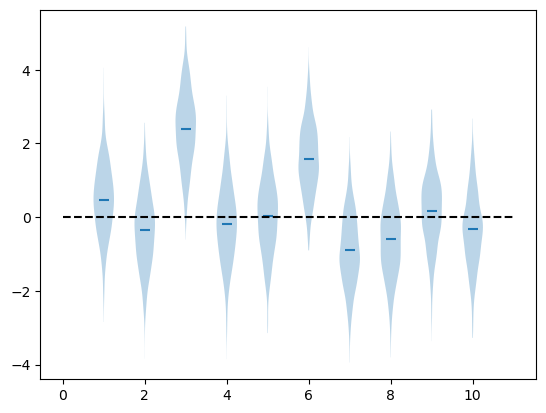

In [1]:
# library import

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(5)       # fixing the randomization seed

# initialization

k=10;                   # number of arms

q_star=np.random.normal(0,1,k);     # average reward in each arm
sigma=np.ones(k);                   # standard deviation of reward for each arm

data=[np.random.normal(q_star[i],sigma[i],1000) for i in range(0,k)];

plt.violinplot(data,showextrema=False, showmeans=True);
plt.plot([0,11],[0,0],linestyle='dashed',color='black')

plt.savefig('arms.png')
plt.show()


## Question 3: $\epsilon$ - Greedy bandits

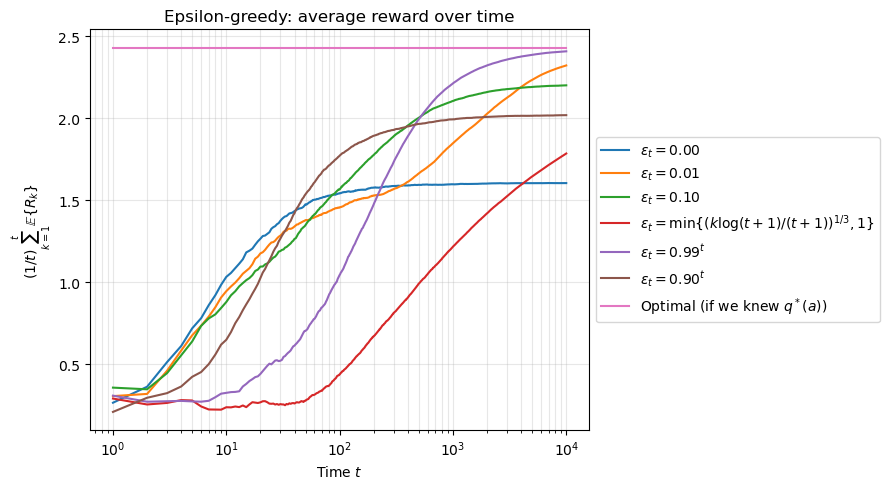

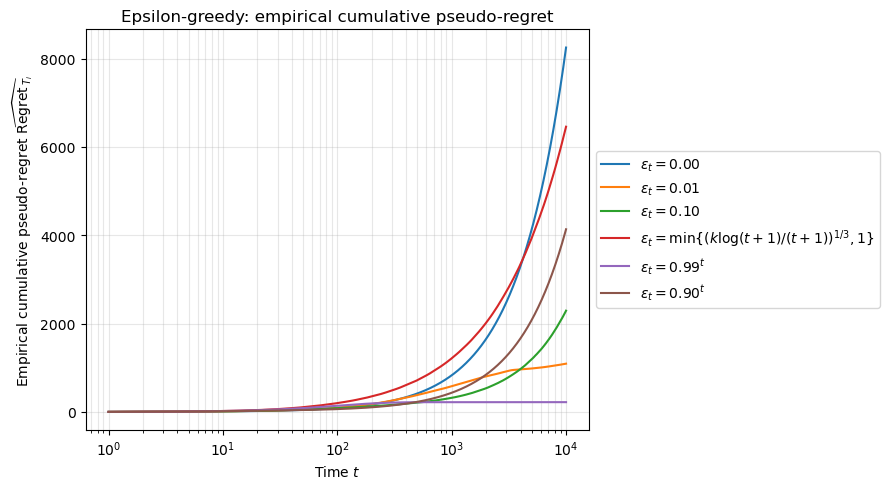

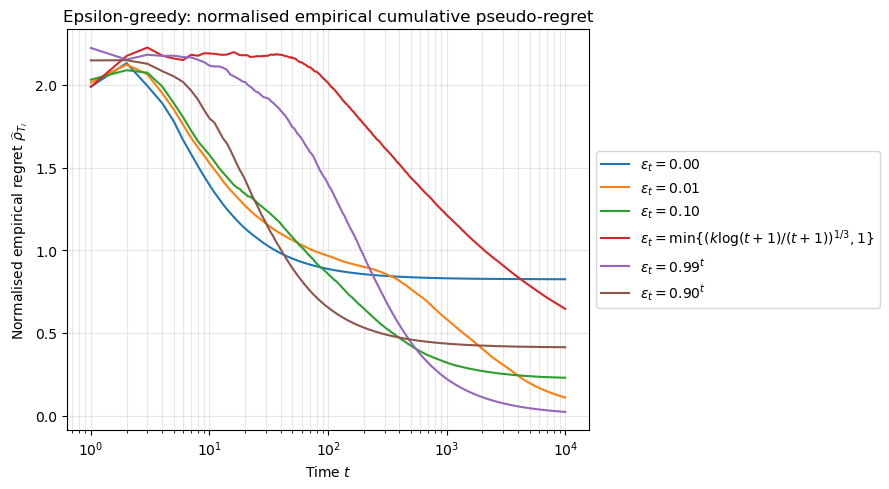

Scenario: $\epsilon_t=0.00$
    empirical cumulative pseudo-regret at T = 8248.2473
    normalised empirical regret at T/10 = 0.830485
    normalised empirical regret at T/2  = 0.825454
    normalised empirical regret at T    = 0.824825
Scenario: $\epsilon_t=0.01$
    empirical cumulative pseudo-regret at T = 1093.4932
    normalised empirical regret at T/10 = 0.584203
    normalised empirical regret at T/2  = 0.196952
    normalised empirical regret at T    = 0.109349
Scenario: $\epsilon_t=0.10$
    empirical cumulative pseudo-regret at T = 2293.0479
    normalised empirical regret at T/10 = 0.321068
    normalised empirical regret at T/2  = 0.238414
    normalised empirical regret at T    = 0.229305
Scenario: $\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$
    empirical cumulative pseudo-regret at T = 6456.7416
    normalised empirical regret at T/10 = 1.214272
    normalised empirical regret at T/2  = 0.786389
    normalised empirical regret at T    = 0.645674
Scenario: $\epsilon_t=

In [2]:
# epsilon-greedy bandit: Question 3 regret experiment

T=10000;                            # horizon
rerun=100;                          # number of reruns

# q_star is known in this synthetic experiment, so its maximum is the
# optimal expected reward.  It is used only to evaluate a selected action.
R_star=np.max(q_star);

legend=[];
average_reward_all=[];
regret_hat_all=[];
rho_hat_all=[];

for scenario in range(6):       # we test 6 scenarios:
                                # 3 with fixed epsilon and
                                # 3 with time varying epsilon
    R=np.zeros((T,rerun));           # rewards received
    cumulative_regret=np.zeros((T,rerun)); # cumulative pseudo-regret in each rerun

    match scenario:
        case 0:                      # scenario 0: epsilon fixed to 0
            epsilon_t=lambda t: 0;
            legend.append(r'$\epsilon_t=0.00$');
        case 1:                      # scenario 1: epsilon fixed to 0.01
            epsilon_t=lambda t: 0.01;
            legend.append(r'$\epsilon_t=0.01$');
        case 2:                      # scenario 2: epsilon fixed to 0.1
            epsilon_t=lambda t: 0.1;
            legend.append(r'$\epsilon_t=0.10$');
        case 3:                      # scenario 3: epsilon varying; t+1 accounts for Python's zero-based indexing
            epsilon_t=lambda t: min((k*np.log(t+1)/(t+1))**(1/3),1);
            legend.append(r'$\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$');
        case 4:                      # scenario 4: epsilon diminishing
            epsilon_t=lambda t: 0.99**t; # exponentially (slowly)
            legend.append(r'$\epsilon_t=0.99^t$');
        case 5:                      # scenario 5: epsilon diminishing
            epsilon_t=lambda t: 0.90**t; # exponentially (quicker); corrected from 0.99**t
            legend.append(r'$\epsilon_t=0.90^t$');

    for r in range(0,rerun):
        Q=np.zeros((k,T+1));        # empirical mean
        N=np.zeros((k,T+1));        # number of times an arm used
        A=np.zeros(T,dtype=int);    # arms used

        for t in range(0,T):
            epsilon=epsilon_t(t);

            if (np.random.uniform()<epsilon):
                A[t]=int(np.random.randint(0,k));   # exploration
            else:
                A[t]=int(np.argmax(Q[:,t]));        # exploitation

            R[t,r]=np.random.normal(q_star[A[t]], sigma[A[t]]);

            # Instantaneous pseudo-regret evaluates the action just selected;
            # q_star is not used by the policy or by the learning update.
            instantaneous_regret=R_star-q_star[A[t]];
            # Accumulate pseudo-regret along this rerun.
            if t==0:
                cumulative_regret[t,r]=instantaneous_regret;
            else:
                cumulative_regret[t,r]=cumulative_regret[t-1,r]+instantaneous_regret;

            # Original empirical-mean learning update (uses sampled reward only).
            for i in range(0,k):
                N[i,t+1]=N[i,t];
                Q[i,t+1]=Q[i,t];
                if (A[t]==i):
                    N[i,t+1]=N[i,t]+1;
                    Q[i,t+1]=Q[i,t]+(1/N[i,t+1])*(R[t,r]-Q[i,t]);

    # Average cumulative pseudo-regret across reruns.
    # Preserve the workshop's original average-reward diagnostic.
    average=np.array([np.mean(R[0:t+1,:]) for t in range(T)]);
    average_reward_all.append(average);

    regret_hat=np.mean(cumulative_regret,axis=1);
    # Normalise by the number of completed decisions (t+1 under zero-based indexing).
    rho_hat=regret_hat/np.arange(1,T+1);
    regret_hat_all.append(regret_hat);
    rho_hat_all.append(rho_hat);

# Original workshop figure: average reward over time for all epsilon schedules.
plt.figure(figsize=(9,5));
for scenario in range(6):
    plt.semilogx(range(1,T),average_reward_all[scenario][1:T],label=legend[scenario]);
plt.semilogx([1,T],[R_star,R_star],label=r'Optimal (if we knew $q^*(a)$)');
plt.grid(True,which='both',alpha=0.3);
plt.xlabel('Time $t$');
plt.ylabel(r'$(1/t)\sum_{k=1}^t \mathbb{E}\{R_k\}$');
plt.title('Epsilon-greedy: average reward over time');
plt.legend(loc='center left',bbox_to_anchor=(1,0.5));
plt.tight_layout();
plt.savefig('epsilon.png',bbox_inches='tight');
plt.show();
# Figure 1: empirical mean cumulative pseudo-regret.
plt.figure(figsize=(9,5));
for scenario in range(6):
    plt.semilogx(range(1,T+1),regret_hat_all[scenario],label=legend[scenario]);
plt.grid(True,which='both',alpha=0.3);
plt.xlabel('Time $t$');
plt.ylabel(r'Empirical cumulative pseudo-regret $\widehat{\operatorname{Regret}}_{T_i}$');
plt.title('Epsilon-greedy: empirical cumulative pseudo-regret');
plt.legend(loc='center left',bbox_to_anchor=(1,0.5));
plt.tight_layout();
plt.savefig('epsilon_cumulative_regret.png',bbox_inches='tight');
plt.show();

# Figure 2 (main diagnostic): sublinear regret is numerically suggested when
# normalised empirical regret keeps decreasing towards zero, rather than levelling off.
plt.figure(figsize=(9,5));
for scenario in range(6):
    plt.semilogx(range(1,T+1),rho_hat_all[scenario],label=legend[scenario]);
plt.grid(True,which='both',alpha=0.3);
plt.xlabel('Time $t$');
plt.ylabel(r'Normalised empirical regret $\widehat{\rho}_{T_i}$');
plt.title('Epsilon-greedy: normalised empirical cumulative pseudo-regret');
plt.legend(loc='center left',bbox_to_anchor=(1,0.5));
plt.tight_layout();
plt.savefig('epsilon_normalised_regret.png',bbox_inches='tight');
plt.show();

# Concise late-horizon numerical summary.  These finite simulations provide
# evidence only; they do not prove an asymptotic regret rate.
tenth_index=T//10-1;
half_index=T//2-1;
for scenario in range(6):
    print(f'Scenario: {legend[scenario]}')
    print(f'    empirical cumulative pseudo-regret at T = {regret_hat_all[scenario][-1]:.4f}')
    print(f'    normalised empirical regret at T/10 = {rho_hat_all[scenario][tenth_index]:.6f}')
    print(f'    normalised empirical regret at T/2  = {rho_hat_all[scenario][half_index]:.6f}')
    print(f'    normalised empirical regret at T    = {rho_hat_all[scenario][-1]:.6f}')

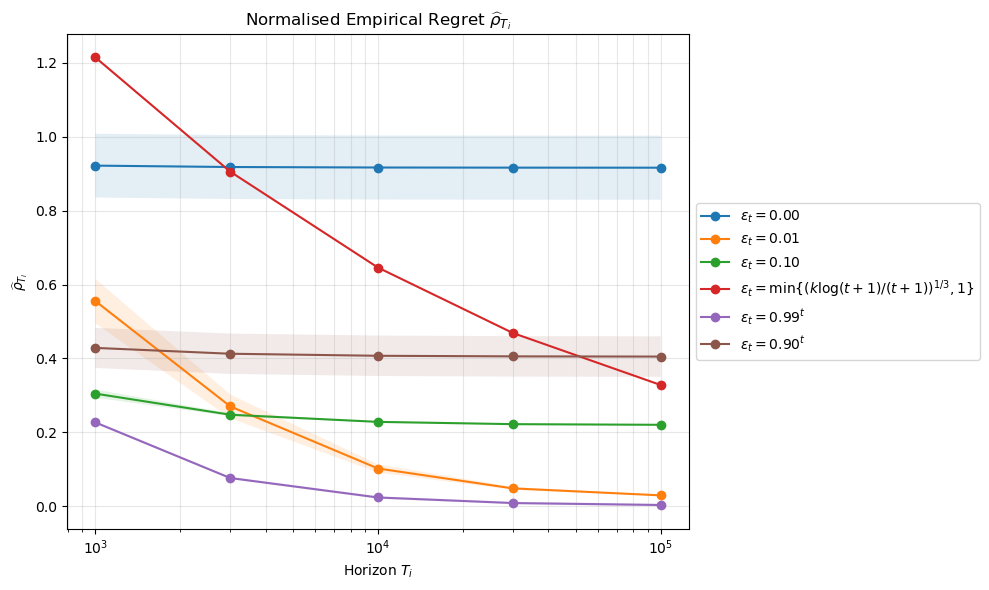

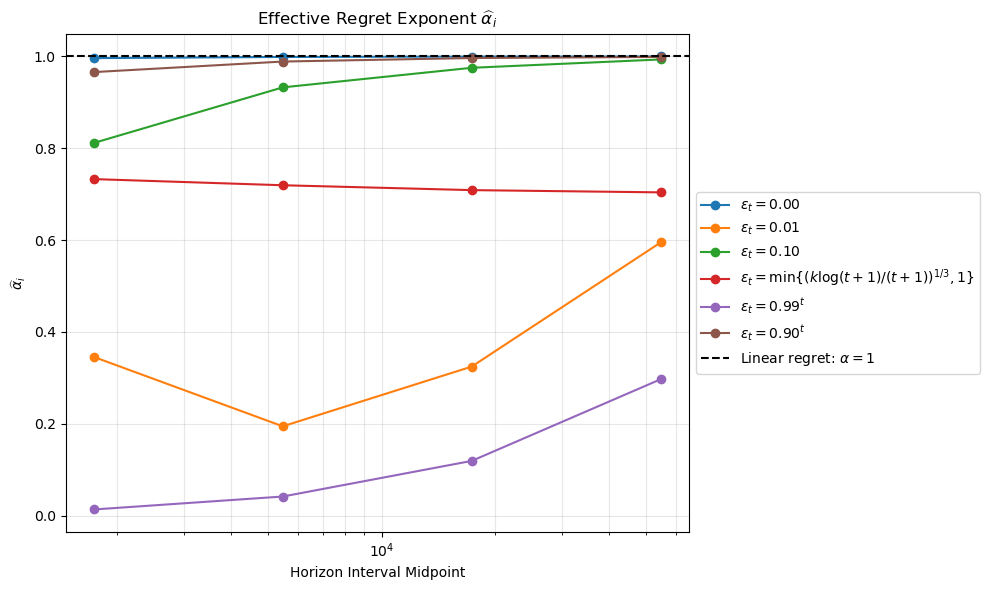

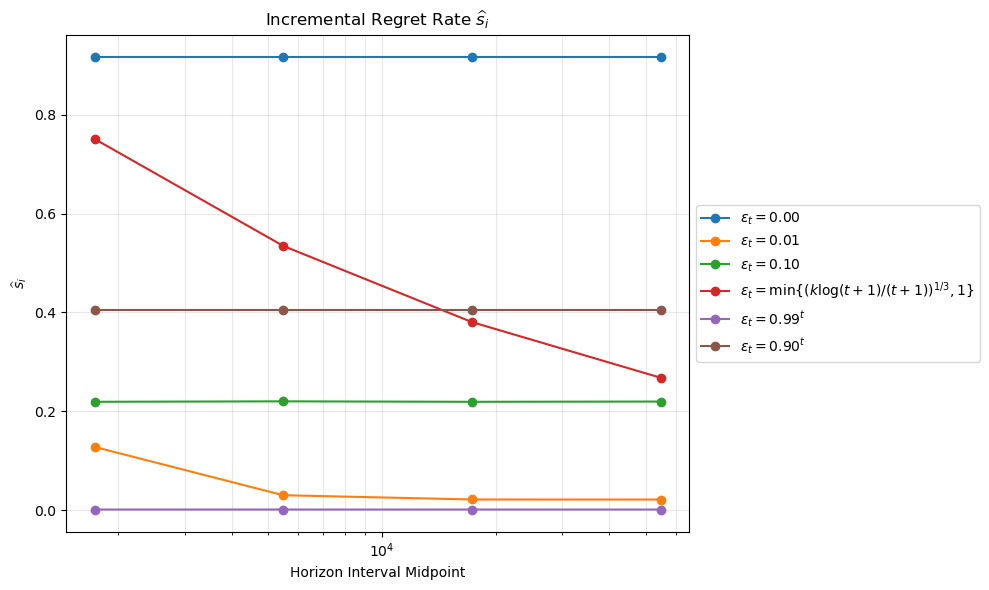

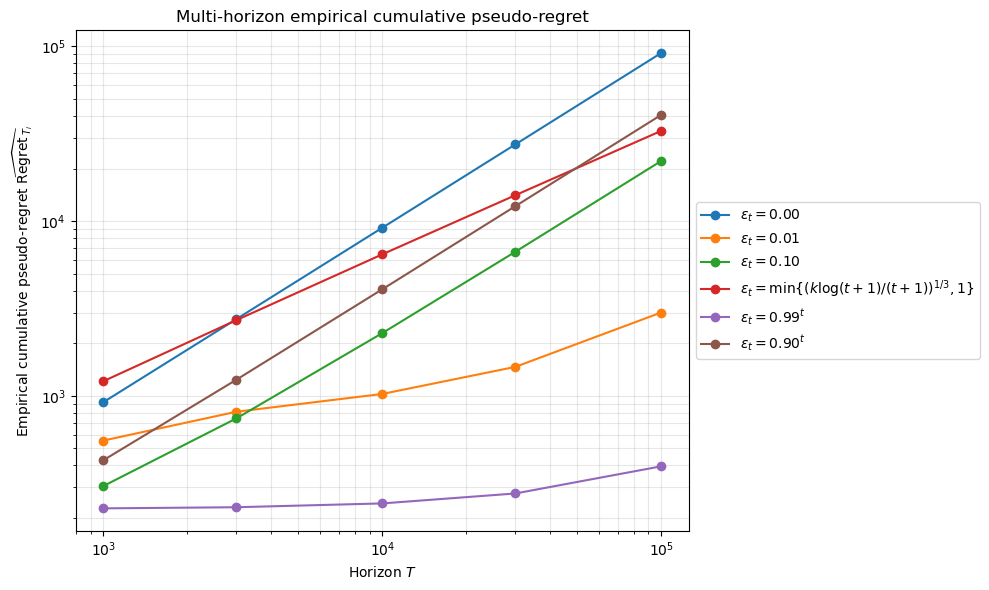


LaTeX-ready compact Q3 numerical summary:
\begin{tabular}{lrrrrrrrrrl}
\toprule
Schedule & $\widehat{\rho}_{T_{\max}}$ & $\widehat{s}_1$ & $\widehat{s}_2$ & $\widehat{s}_3$ & $\widehat{s}_4$ & $\widehat{\alpha}_1$ & $\widehat{\alpha}_2$ & $\widehat{\alpha}_3$ & $\widehat{\alpha}_4$ & Classification \\
\midrule
$\epsilon_t=0$ & 0.915771 & 0.915715 & 0.915715 & 0.915715 & 0.915715 & 0.996278 & 0.998808 & 0.999626 & 0.999881 & linear \\
$\epsilon_t=0.01$ & 0.029987 & 0.128187 & 0.030604 & 0.021975 & 0.021906 & 0.345596 & 0.194581 & 0.324591 & 0.594813 & linear \\
$\epsilon_t=0.10$ & 0.220710 & 0.219439 & 0.220342 & 0.219408 & 0.219951 & 0.811545 & 0.932582 & 0.975197 & 0.993360 & linear \\
$\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$ & 0.328312 & 0.750699 & 0.534459 & 0.380526 & 0.268061 & 0.732853 & 0.719463 & 0.708854 & 0.703965 & sublinear \\
$\epsilon_t=0.99^t$ & 0.003951 & 0.001699 & 0.001697 & 0.001697 & 0.001697 & 0.013520 & 0.041726 & 0.119257 & 0.296956 & emerging linear-regr

In [2]:
# Robust multi-horizon epsilon-greedy regret diagnostic
#
# Multiple geometrically increasing horizons help distinguish a persistent
# asymptotic trend from behaviour that is only transient near T=10000.

horizons=np.array([1000,3000,10000,30000,100000],dtype=int)
T_max=int(np.max(horizons))
rerun_robust=500                 # reduce to 200 for speed, or increase to 1000
robust_rng=np.random.default_rng(20260813) # reproducible; does not regenerate q_star
R_star_robust=np.max(q_star)

schedule_labels=[
    r'$\epsilon_t=0.00$',
    r'$\epsilon_t=0.01$',
    r'$\epsilon_t=0.10$',
    r'$\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$',
    r'$\epsilon_t=0.99^t$',
    r'$\epsilon_t=0.90^t$'
]
epsilon_schedules=[
    lambda t: 0,
    lambda t: 0.01,
    lambda t: 0.10,
    lambda t: min((k*np.log(t+1)/(t+1))**(1/3),1), # t+1: zero-based indexing
    lambda t: 0.99**t,
    lambda t: 0.90**t             # corrected scenario 6
]

# cumulative_regret_samples[s,h,r] stores the cumulative pseudo-regret for
# schedule s, horizon h, and rerun r. One trajectory to T_max supplies every
# checkpoint, avoiding a separate simulation for every requested horizon.
cumulative_regret_samples=np.zeros((6,len(horizons),rerun_robust))
checkpoint_by_step={int(T):i for i,T in enumerate(horizons)}
rows=np.arange(rerun_robust)

for scenario,epsilon_t in enumerate(epsilon_schedules):
    # Each row is an independent rerun. Vectorising over rows preserves the
    # lecturer's epsilon-greedy and empirical-mean update logic while avoiding
    # a prohibitively slow Python loop over reruns.
    Q=np.zeros((rerun_robust,k))
    N=np.zeros((rerun_robust,k))
    cumulative=np.zeros(rerun_robust)

    for t in range(T_max):
        epsilon=epsilon_t(t)
        explore=robust_rng.random(rerun_robust)<epsilon
        actions=np.argmax(Q,axis=1) # exploitation uses learned estimates only
        n_explore=np.count_nonzero(explore)
        if n_explore:
            actions[explore]=robust_rng.integers(0,k,size=n_explore)

        # Sampled rewards alone drive learning. q_star is consulted only after
        # selection to evaluate delta_t = R_star - q_star[A_t].
        rewards=robust_rng.normal(q_star[actions],sigma[actions])
        delta_t=R_star_robust-q_star[actions]
        cumulative+=delta_t

        # Same incremental empirical-mean update as the original experiment.
        N[rows,actions]+=1
        Q[rows,actions]+=(rewards-Q[rows,actions])/N[rows,actions]

        completed_steps=t+1
        if completed_steps in checkpoint_by_step:
            h=checkpoint_by_step[completed_steps]
            cumulative_regret_samples[scenario,h,:]=cumulative

# Monte Carlo means and standard errors. Normalising by the fixed horizon also
# scales its standard error; 1.96 standard errors gives an approximate 95% CI.
regret_hat_h=np.mean(cumulative_regret_samples,axis=2)
regret_se_h=np.std(cumulative_regret_samples,axis=2,ddof=1)/np.sqrt(rerun_robust)
rho_hat_h=regret_hat_h/horizons[None,:]
rho_se_h=regret_se_h/horizons[None,:]
rho_ci_low=rho_hat_h-1.96*rho_se_h
rho_ci_high=rho_hat_h+1.96*rho_se_h

# Local effective exponent between adjacent horizons. It estimates the local
# power alpha in empirical cumulative pseudo-regret approximately C*T**alpha; zero regret gives NaN.
alpha_eff=np.full((6,len(horizons)-1),np.nan)
for scenario in range(6):
    for i in range(len(horizons)-1):
        r0,r1=regret_hat_h[scenario,i:i+2]
        if r0>0 and r1>0:
            alpha_eff[scenario,i]=(np.log(r1)-np.log(r0))/(np.log(horizons[i+1])-np.log(horizons[i]))
midpoints=np.sqrt(horizons[:-1]*horizons[1:])

# Incremental regret rate is the slope of mean cumulative regret over each
# horizon interval. A positive late plateau supports linear regret, whereas
# continued decay toward zero supports sublinear regret.
incremental_regret_rate=np.diff(regret_hat_h,axis=1)/np.diff(horizons)[None,:]

# Diagnostic 1: direct numerical analogue of normalised empirical pseudo-regret tending to zero.
plt.figure(figsize=(10,6))
for scenario,label in enumerate(schedule_labels):
    plt.semilogx(horizons,rho_hat_h[scenario],marker='o',label=label)
    plt.fill_between(horizons,rho_ci_low[scenario],rho_ci_high[scenario],alpha=0.12)
plt.grid(True,which='both',alpha=0.3)
plt.xlabel(r'Horizon $T_i$')
plt.ylabel(r'$\widehat{\rho}_{T_i}$')
plt.title(r'Normalised Empirical Regret $\widehat{\rho}_{T_i}$')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.savefig('epsilon_multihorizon_normalised_regret.png',bbox_inches='tight')
plt.show()

# Diagnostic 2: local growth exponent; alpha near 1 indicates linear growth.
plt.figure(figsize=(10,6))
for scenario,label in enumerate(schedule_labels):
    plt.semilogx(midpoints,alpha_eff[scenario],marker='o',label=label)
plt.axhline(1,color='black',linestyle='--',label=r'Linear regret: $\alpha=1$')
plt.grid(True,which='both',alpha=0.3)
plt.xlabel(r'Horizon Interval Midpoint')
plt.ylabel(r'$\widehat{\alpha}_i$')
plt.title(r'Effective Regret Exponent $\widehat{\alpha}_i$')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.savefig('epsilon_effective_regret_exponent.png',bbox_inches='tight')
plt.show()

# Diagnostic 3: interval slopes reveal a positive linear-regret floor even
# while normalised empirical pseudo-regret is still falling because of a transient term.
plt.figure(figsize=(10,6))
for scenario,label in enumerate(schedule_labels):
    plt.semilogx(midpoints,incremental_regret_rate[scenario],marker='o',label=label)
plt.grid(True,which='both',alpha=0.3)
plt.xlabel(r'Horizon Interval Midpoint')
plt.ylabel(r'$\widehat{s}_i$')
plt.title(r'Incremental Regret Rate $\widehat{s}_i$')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.savefig('epsilon_incremental_regret_rate.png',bbox_inches='tight')
plt.show()

# Diagnostic 4: supplementary log-log view of cumulative-regret growth.
plt.figure(figsize=(10,6))
for scenario,label in enumerate(schedule_labels):
    plt.loglog(horizons,regret_hat_h[scenario],marker='o',label=label)
plt.grid(True,which='both',alpha=0.3)
plt.xlabel('Horizon $T$')
plt.ylabel(r'Empirical cumulative pseudo-regret $\widehat{\operatorname{Regret}}_{T_i}$')
plt.title('Multi-horizon empirical cumulative pseudo-regret')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.savefig('epsilon_multihorizon_cumulative_regret.png',bbox_inches='tight')
plt.show()

# Policy-agnostic classifier: it receives numerical diagnostics only. Schedule
# identity and epsilon values are deliberately unavailable to this function.
def classify_regret(rho,alpha_values,rate_values,relative_tolerance=0.05):
    """Classify the late-horizon regret trend using scale-free comparisons."""
    late_rho=np.asarray(rho[-3:],dtype=float)
    late_alpha=np.asarray(alpha_values[-3:],dtype=float)
    late_rates=np.asarray(rate_values[-3:],dtype=float)

    finite=(np.all(np.isfinite(late_rho)) and np.all(np.isfinite(late_alpha))
            and np.all(np.isfinite(late_rates)))
    if not finite or np.any(late_rates<=0):
        return ('inconclusive at the simulated horizons',
                'late-horizon diagnostics contain non-finite or non-positive rates')

    # A linear component appears as a positive plateau in the interval slopes.
    # Stability is relative to their own scale, so a small plateau is not
    # mistaken for decay merely because its absolute magnitude is small.
    final_two_rates=late_rates[-2:]
    rate_scale=max(np.mean(np.abs(final_two_rates)),np.finfo(float).eps)
    plateau_relative_span=np.ptp(final_two_rates)/rate_scale
    positive_plateau=plateau_relative_span<=relative_tolerance

    # Persistent sublinear decay requires each of the last two rate ratios to
    # remain materially below one, not simply one downward fluctuation.
    rate_ratios=late_rates[1:]/late_rates[:-1]
    persistent_rate_decay=np.all(rate_ratios<1-relative_tolerance)
    rho_decreasing=np.all(np.diff(late_rho)<0)
    alpha_below_one=np.all(late_alpha<1)
    alpha_moving_toward_one=(abs(1-late_alpha[-1])<abs(1-late_alpha[0]))

    # For R(T)=C+cT, rho(T)-c is the remaining transient contribution C/T.
    # Its contraction supports a linear interpretation even while rho falls.
    transient_gap=late_rho-late_rates
    transient_shrinking=abs(transient_gap[-1])<abs(transient_gap[-2])

    if (persistent_rate_decay and rho_decreasing and alpha_below_one
            and not alpha_moving_toward_one):
        classification='numerically consistent with sublinear regret'
        reason=(f'late incremental-rate ratios are {rate_ratios[0]:.3f} and '
                f'{rate_ratios[1]:.3f} (persistent decay), normalised empirical regret decreases, and '
                f'the effective regret exponent remains below 1 ({late_alpha[0]:.3f} to '
                f'{late_alpha[-1]:.3f}) without moving toward 1')
        return classification,reason

    if positive_plateau and (alpha_moving_toward_one or transient_shrinking):
        # An emerging component is identified from relative transient dominance,
        # not from the absolute size of the regret rate. At the final horizon the
        # residual rho-rate term still exceeds the plateau contribution itself.
        transient_dominated=(transient_gap[-1]>late_rates[-1])
        if transient_dominated and alpha_moving_toward_one:
            classification='numerically consistent with an emerging linear-regret component'
            reason=(f'the last two incremental rates form a positive plateau '
                    f'(relative span {plateau_relative_span:.2%}), the effective regret exponent rises '
                    f'toward 1 ({late_alpha[0]:.3f} to {late_alpha[-1]:.3f}), '
                    'and the remaining transient contribution still dominates '
                    'the plateau component')
        else:
            classification='numerically consistent with linear regret'
            reason=(f'the last two incremental rates form a positive plateau '
                    f'(relative span {plateau_relative_span:.2%}); the effective regret exponent '
                    f'changes from {late_alpha[0]:.3f} to {late_alpha[-1]:.3f}, '
                    'and the normalised-regret transient is contracting')
        return classification,reason

    return ('inconclusive at the simulated horizons',
            f'late diagnostics conflict: rate ratios are {rate_ratios[0]:.3f} '
            f'and {rate_ratios[1]:.3f}, while the effective regret exponent changes from '
            f'{late_alpha[0]:.3f} to {late_alpha[-1]:.3f}')

classifications=[]
classification_reasons=[]
for row in range(len(schedule_labels)):
    classification,reason=classify_regret(
        rho_hat_h[row],alpha_eff[row],incremental_regret_rate[row])
    classifications.append(classification)
    classification_reasons.append(reason)
# Convert the policy-agnostic classifier wording into concise report labels.
# These labels are derived from the existing classifier output, not assigned
# independently by schedule.
def concise_classification(classification):
    report_label=classification.removeprefix('numerically consistent with ')
    if report_label.startswith('an '):
        report_label=report_label[3:]
    if report_label.endswith(' regret'):
        report_label=report_label[:-len(' regret')]
    return report_label

compact_classifications=[concise_classification(value) for value in classifications]
latex_schedule_names=[
    r'$\epsilon_t=0$',
    r'$\epsilon_t=0.01$',
    r'$\epsilon_t=0.10$',
    r'$\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$',
    r'$\epsilon_t=0.99^t$',
    r'$\epsilon_t=0.90^t$'
]

# One compact, LaTeX-ready table reports the three Q2 diagnostics directly:
# final normalised empirical regret, every incremental rate, and every
# effective exponent. The numerical arrays above are used without recomputation.
print('\nLaTeX-ready compact Q3 numerical summary:')
print(r'\begin{tabular}{lrrrrrrrrrl}')
print(r'\toprule')
print(r'Schedule & $\widehat{\rho}_{T_{\max}}$ & '
      r'$\widehat{s}_1$ & $\widehat{s}_2$ & $\widehat{s}_3$ & $\widehat{s}_4$ & '
      r'$\widehat{\alpha}_1$ & $\widehat{\alpha}_2$ & '
      r'$\widehat{\alpha}_3$ & $\widehat{\alpha}_4$ & Classification \\')
print(r'\midrule')
for row,(name,classification) in enumerate(zip(latex_schedule_names,compact_classifications)):
    values=[rho_hat_h[row,-1],*incremental_regret_rate[row],*alpha_eff[row]]
    formatted=' & '.join(f'{value:.6f}' for value in values)
    print(f'{name} & {formatted} & {classification} ' + r'\\')
print(r'\bottomrule')
print(r'\end{tabular}')
interval_text='; '.join(
    f'i={i+1}: {horizons[i]} -> {horizons[i+1]}'
    for i in range(len(horizons)-1))
print(f'Interval mapping for $\\widehat{{s}}_i$ and $\\widehat{{\\alpha}}_i$: {interval_text}')
print(f'$T_{{\\max}}={T_max}$ for $\\widehat{{\\rho}}_{{T_{{\\max}}}}$.')

# Concise assessment generated from the same policy-agnostic classifications.
summary_names=[
    'epsilon_t = 0',
    'epsilon_t = 0.01',
    'epsilon_t = 0.10',
    'polynomial decay',
    'epsilon_t = 0.99^t',
    'epsilon_t = 0.90^t'
]
print('\nNumerical assessment from late-horizon diagnostics:')
for name,classification in zip(summary_names,compact_classifications):
    print(f'\n{name}:')
    print(f'    {classification}')
print('\nThese finite simulations do not prove the asymptotic regret regime.')

### Q3 analysis - Which epsilon-greedy schedules have sublinear regret?

For arm $a$, let $q^*(a)$ denote its true expected reward and let

$$
R^*=\max_a q^*(a).
$$

The empirical mean cumulative pseudo-regret at horizon $T_i$ is denoted by $\widehat{\operatorname{Regret}}_{T_i}$. The main definition-based diagnostic is

$$
\widehat{\rho}_{T_i}
=
\frac{\widehat{\operatorname{Regret}}_{T_i}}{T_i}.
$$

Sublinear regret requires $\widehat{\rho}_{T_i}\to 0$ as the horizons increase. To avoid mistaking a long finite-horizon transient for sublinear growth, the analysis also uses the incremental regret rate

$$
\widehat{s}_i
=
\frac{
\widehat{\operatorname{Regret}}_{T_{i+1}}
-
\widehat{\operatorname{Regret}}_{T_i}
}{T_{i+1}-T_i},
$$

and the local effective exponent

$$
\widehat{\alpha}_i
=
\frac{
\log\widehat{\operatorname{Regret}}_{T_{i+1}}
-
\log\widehat{\operatorname{Regret}}_{T_i}
}{
\log T_{i+1}-\log T_i
}.
$$

A positive plateau in $\widehat{s}_i$ indicates a linear component, whereas persistent decay of $\widehat{s}_i$ toward zero supports a sublinear interpretation. The saved compact numerical table reports $\widehat{\rho}_{T_{\max}}$, all four values of $\widehat{s}_i$, all four values of $\widehat{\alpha}_i$, and the policy-agnostic classification for every schedule. The classifier gives:

| Epsilon schedule | Late-horizon numerical classification | Decisive evidence |
|---|---|---|
| $\epsilon_t=0$ | Linear regret | $\widehat{s}_i$ plateaus near 0.9157 and $\widehat{\alpha}_i\to 1$. Greedy runs that commit to a suboptimal arm continue accumulating cumulative pseudo-regret. |
| $\epsilon_t=0.01$ | Linear regret | The last values of $\widehat{s}_i$ stabilise near 0.02191. The falling $\widehat{\rho}_{T_i}$ is a shrinking transient of the form $C/T_i+c$, not evidence that $c=0$. |
| $\epsilon_t=0.10$ | Linear regret | $\widehat{s}_i$ forms a clear positive plateau near 0.21995 and $\widehat{\alpha}_i$ rises to approximately 0.993. Persistent random exploration creates a nonzero pseudo-regret rate. |
| $\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$ | **Sublinear regret** | $\widehat{\rho}_{T_i}$ keeps decreasing; $\widehat{s}_i$ falls approximately $0.7507\to 0.5345\to 0.3805\to 0.2681$; and $\widehat{\alpha}_i$ remains near 0.70 rather than approaching 1. The $t+1$ form accounts for Python's zero-based indexing. |
| $\epsilon_t=0.99^t$ | Emerging linear-regret component | $\widehat{s}_i$ stops decreasing and plateaus near 0.001697 while $\widehat{\alpha}_i$ rises. Its small magnitude does not make the cumulative pseudo-regret sublinear. |
| $\epsilon_t=0.90^t$ | Linear regret | $\widehat{s}_i$ plateaus near 0.40494 and $\widehat{\alpha}_i\to 1$, showing that some runs stop exploring after committing to a suboptimal arm. |

**Conclusion.** Of the six tested schedules, only

$$
\epsilon_t
=
\min\left\{
\left(\frac{k\log(t+1)}{t+1}\right)^{1/3},
1
\right\}
$$

is numerically consistent with sublinear regret over the simulated horizons. The other five exhibit a positive late-horizon incremental pseudo-regret rate and are numerically consistent with linear regret or an emerging linear component. These finite-horizon simulations provide evidence about the growth regime; they do not constitute a mathematical proof of asymptotic regret.

## Questions 4-5: UCB bandits

This section investigates whether UCB learns each arm's true value and compares UCB regret with all six epsilon-greedy schedules. It reuses the fixed `q_star`, learns only from sampled rewards, and averages results over 300 reproducible reruns.

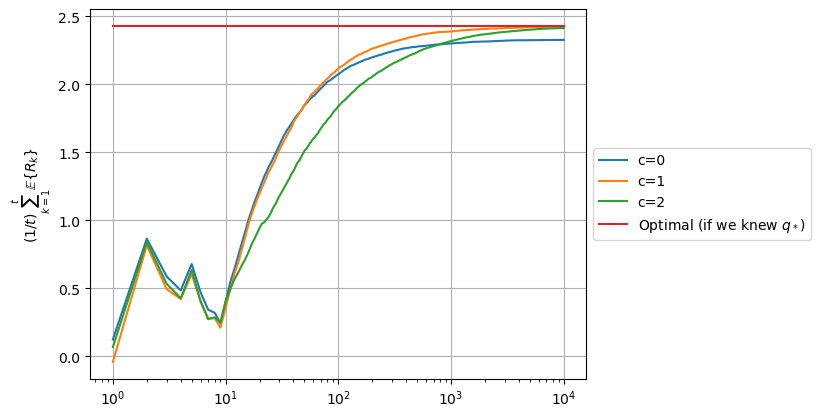

In [ ]:
# Upper-Confidence Bound (UCB)

T=10000;                          # horizon
rerun=100;                        # number of reruns

legend=[];
for scenario in range(3):
    R=np.zeros((T,rerun));        # rewards received
    average=np.zeros(T);          # average reward over time
    
    match scenario:
        case 0:                   # scenario 0: c=0 (no exploration)
            c=0;
            legend.append('c=0');
        case 1:                   # scenario 1: c=1 
            c=1;
            legend.append('c=1');
        case 2:                   # scenario 2: c=2
            c=2;
            legend.append('c=2');
    
    for r in range(0,rerun):
        Q=np.zeros((k,T+1));        # empirical mean
        N=np.zeros((k,T+1));        # number of times an arm used
        A=np.zeros(T,dtype=int);    # arms used
        
        for t in range(0,T):
            if t < k:
                A[t] = t                       # fixed: pull each arm once first,
            else:                               # avoids 0/0 = nan in the UCB term at t=0
                A[t]=int(np.argmax(Q[:,t]+c*np.sqrt(np.log(t+1)/N[:,t])));
            
            R[t,r]=np.random.normal(q_star[A[t]], sigma[A[t]]);
            
            for i in range(0,k):
                N[i,t+1]=N[i,t];
                Q[i,t+1]=Q[i,t];
                if (A[t]==i):
                    N[i,t+1]=N[i,t]+1;
                    Q[i,t+1]=Q[i,t]+(1/N[i,t+1])*(R[t,r]-Q[i,t]);
    
    for t in range(0,T):
        average[t]=np.mean(R[0:t+1,:]);   # fixed: was R[0:t,:] (empty slice at t=0)
    
    plt.semilogx(range(1,T),average[1:T]);

plt.semilogx([1,T],[np.max(q_star),np.max(q_star)]);
legend.append('Optimal (if we knew $q_*$)');

plt.grid()
plt.legend(legend,loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel(r'$(1/t)\sum_{k=1}^t \mathbb{E}\{R_k\}$')

plt.savefig('UCB.png',bbox_inches='tight')
plt.show()


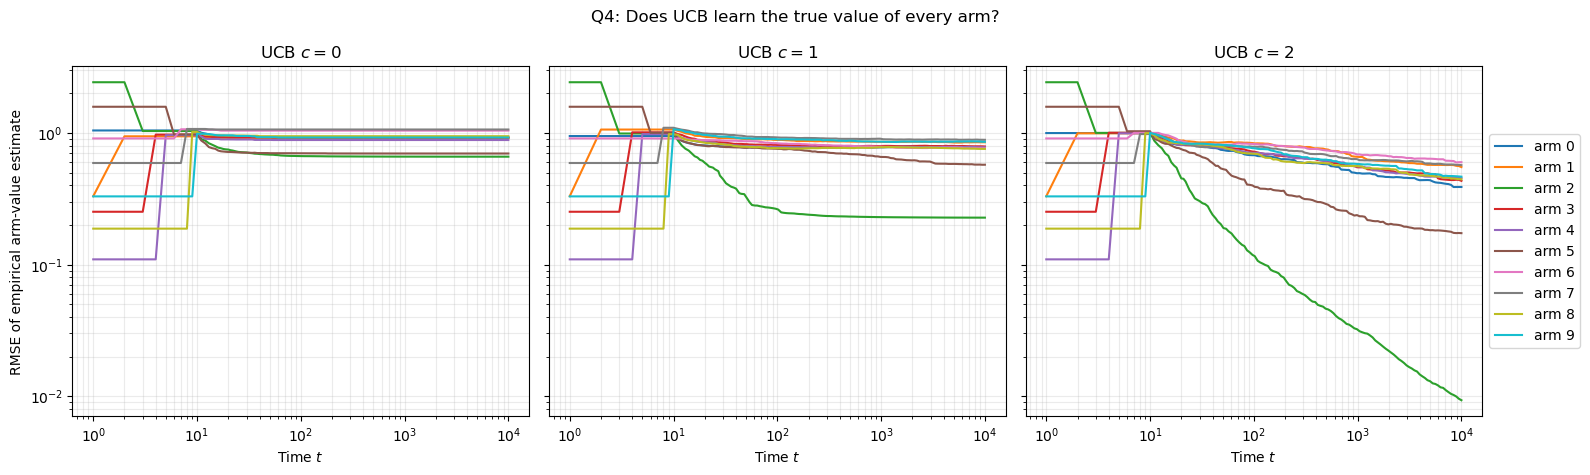

Q4: final UCB arm-value estimates and mean pull counts
True q_star: [ 0.441 -0.331  2.431 -0.252  0.11   1.582 -0.909 -0.592  0.188 -0.33 ]

UCB c=0
  mean Q(T): [ 0.298 -0.411  2.171 -0.234  0.061  1.275 -0.867 -0.615  0.058 -0.344]
  RMSE(T):   [0.921 0.917 0.661 0.924 0.884 0.698 1.043 1.063 0.945 0.924]
  mean N(T): [1.2e+00 1.0e+00 8.4e+03 1.0e+00 1.1e+00 1.6e+03 1.0e+00 1.0e+00 1.1e+00
 1.0e+00]
  mean arm-wise RMSE: 0.8981

UCB c=1
  mean Q(T): [ 0.181 -0.632  2.417 -0.508 -0.195  1.335 -1.07  -0.863 -0.096 -0.62 ]
  RMSE(T):   [0.766 0.85  0.227 0.79  0.779 0.574 0.767 0.887 0.758 0.857]
  mean N(T): [3.0e+00 1.8e+00 9.9e+03 1.9e+00 2.3e+00 4.6e+01 1.4e+00 1.6e+00 2.4e+00
 1.8e+00]
  mean arm-wise RMSE: 0.7254

UCB c=2
  mean Q(T): [ 0.316 -0.459  2.43  -0.321 -0.004  1.526 -1.058 -0.755  0.09  -0.423]
  RMSE(T):   [0.389 0.551 0.009 0.433 0.454 0.173 0.6   0.57  0.445 0.466]
  mean N(T): [9.3e+00 5.3e+00 9.9e+03 5.7e+00 7.2e+00 4.4e+01 3.8e+00 4.4e+00 7.6e+00
 5.3e+00]
  mean 

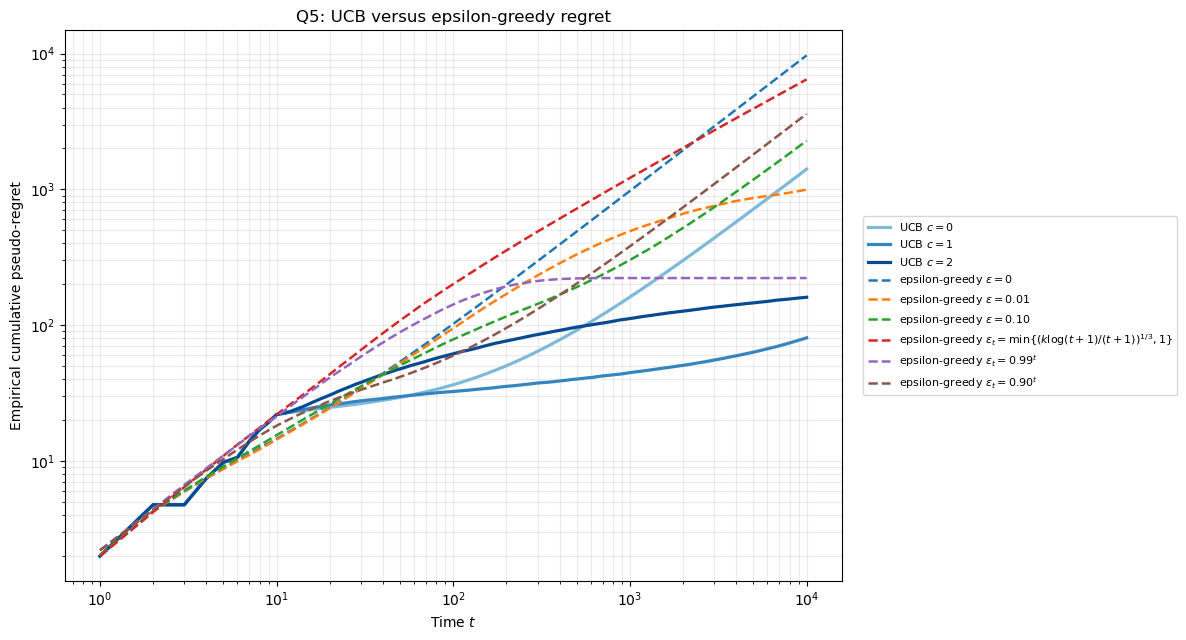


Q5: cumulative pseudo-regret at T=10000 (95% Monte Carlo CI)
  UCB c=0  : regret=  1408.07, regret/T=0.14081, CI=[1052.99,1763.15]
  UCB c=1  : regret=    80.58, regret/T=0.00806, CI=[25.15,136.01]
  UCB c=2  : regret=   160.29, regret/T=0.01603, CI=[158.32,162.26]
  $\epsilon=0$                                    : regret=  9689.07, regret/T=0.96891, CI=[8564.69,10813.45]
  $\epsilon=0.01$                                 : regret=   994.19, regret/T=0.09942, CI=[837.83,1150.55]
  $\epsilon=0.10$                                 : regret=  2278.07, regret/T=0.22781, CI=[2263.00,2293.15]
  $\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$ : regret=  6445.49, regret/T=0.64455, CI=[6431.88,6459.11]
  $\epsilon_t=0.99^t$                             : regret=   221.98, regret/T=0.02220, CI=[219.81,224.15]
  $\epsilon_t=0.90^t$                             : regret=  3592.71, regret/T=0.35927, CI=[2886.14,4299.29]

Numerical conclusions for Q4-Q5:
  Q4: exploratory UCB (c=1,2) progressively est

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Questions 4-7: reproducible numerical investigation on the existing bandit.
# q_star and sigma are reused from the initialization cell and are never exposed
# to an algorithm for action selection or learning; they are used only to score
# pseudo-regret after an action has been selected.
T_q47=10000
rerun_q47=300
R_star_q47=np.max(q_star)
optimal_arm_q47=int(np.argmax(q_star))
plot_steps_q47=np.unique(np.geomspace(1,T_q47,160).astype(int))
plot_index_q47={int(step):i for i,step in enumerate(plot_steps_q47)}
rows_q47=np.arange(rerun_q47)

def simulate_ucb_q47(c,seed):
    """Run the workshop UCB update and retain regret/estimation diagnostics."""
    rng=np.random.default_rng(seed)
    Q=np.zeros((rerun_q47,k))
    N=np.zeros((rerun_q47,k))
    cumulative=np.zeros(rerun_q47)
    regret_samples=np.zeros((len(plot_steps_q47),rerun_q47))
    rmse_by_arm=np.zeros((len(plot_steps_q47),k))
    mean_Q=np.zeros((len(plot_steps_q47),k))
    mean_N=np.zeros((len(plot_steps_q47),k))

    for t in range(T_q47):
        # Pull every arm once before applying UCB, matching the corrected
        # workshop implementation and avoiding division by zero.
        if t<k:
            actions=np.full(rerun_q47,t,dtype=int)
        else:
            bonus=c*np.sqrt(np.log(t+1)/N)
            actions=np.argmax(Q+bonus,axis=1)

        rewards=rng.normal(q_star[actions],sigma[actions])
        cumulative+=R_star_q47-q_star[actions]
        N[rows_q47,actions]+=1
        Q[rows_q47,actions]+=(rewards-Q[rows_q47,actions])/N[rows_q47,actions]

        completed=t+1
        if completed in plot_index_q47:
            j=plot_index_q47[completed]
            regret_samples[j]=cumulative
            rmse_by_arm[j]=np.sqrt(np.mean((Q-q_star[None,:])**2,axis=0))
            mean_Q[j]=np.mean(Q,axis=0)
            mean_N[j]=np.mean(N,axis=0)
    return {'regret':regret_samples,'rmse':rmse_by_arm,
            'mean_Q':mean_Q,'mean_N':mean_N}

epsilon_labels_q47=[
    r'$\epsilon=0$',r'$\epsilon=0.01$',r'$\epsilon=0.10$',
    r'$\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$',
    r'$\epsilon_t=0.99^t$',r'$\epsilon_t=0.90^t$'
]
epsilon_schedules_q47=[
    lambda t:0,
    lambda t:0.01,
    lambda t:0.10,
    lambda t:min((k*np.log(t+1)/(t+1))**(1/3),1),
    lambda t:0.99**t,
    lambda t:0.90**t
]

def simulate_epsilon_q47(epsilon_t,seed):
    """Run the workshop epsilon-greedy empirical-mean update."""
    rng=np.random.default_rng(seed)
    Q=np.zeros((rerun_q47,k))
    N=np.zeros((rerun_q47,k))
    cumulative=np.zeros(rerun_q47)
    regret_samples=np.zeros((len(plot_steps_q47),rerun_q47))
    for t in range(T_q47):
        epsilon=epsilon_t(t)
        explore=rng.random(rerun_q47)<epsilon
        actions=np.argmax(Q,axis=1)
        n_explore=np.count_nonzero(explore)
        if n_explore:
            actions[explore]=rng.integers(0,k,size=n_explore)
        rewards=rng.normal(q_star[actions],sigma[actions])
        cumulative+=R_star_q47-q_star[actions]
        N[rows_q47,actions]+=1
        Q[rows_q47,actions]+=(rewards-Q[rows_q47,actions])/N[rows_q47,actions]
        completed=t+1
        if completed in plot_index_q47:
            regret_samples[plot_index_q47[completed]]=cumulative
    return regret_samples

# Independent reproducible streams for every Q4-Q5 configuration.
ucb_cs_q47=[0,1,2]
ucb_results_q47={c:simulate_ucb_q47(c,4700+i) for i,c in enumerate(ucb_cs_q47)}
epsilon_results_q47={label:simulate_epsilon_q47(schedule,4800+i)
                     for i,(label,schedule) in enumerate(zip(epsilon_labels_q47,epsilon_schedules_q47))}
# Q4: arm-by-arm UCB estimation error over time.
fig,axes=plt.subplots(1,3,figsize=(16,4.8),sharey=True)
for ax,c in zip(axes,ucb_cs_q47):
    for arm in range(k):
        ax.loglog(plot_steps_q47,ucb_results_q47[c]['rmse'][:,arm],label=f'arm {arm}')
    ax.set_title(f'UCB $c={c}$')
    ax.set_xlabel('Time $t$')
    ax.grid(True,which='both',alpha=0.25)
axes[0].set_ylabel('RMSE of empirical arm-value estimate')
axes[-1].legend(loc='center left',bbox_to_anchor=(1,0.5),ncol=1)
fig.suptitle('Q4: Does UCB learn the true value of every arm?')
fig.tight_layout()
plt.savefig('q4_ucb_arm_value_rmse.png',bbox_inches='tight')
plt.show()

print('Q4: final UCB arm-value estimates and mean pull counts')
print(f'True q_star: {np.array2string(q_star,precision=3)}')
for c in ucb_cs_q47:
    final_Q=ucb_results_q47[c]['mean_Q'][-1]
    final_N=ucb_results_q47[c]['mean_N'][-1]
    final_rmse=ucb_results_q47[c]['rmse'][-1]
    print(f'\nUCB c={c}')
    print(f'  mean Q(T): {np.array2string(final_Q,precision=3)}')
    print(f'  RMSE(T):   {np.array2string(final_rmse,precision=3)}')
    print(f'  mean N(T): {np.array2string(final_N,precision=1)}')
    print(f'  mean arm-wise RMSE: {np.mean(final_rmse):.4f}')

def final_summary_q47(samples):
    final=samples[-1]
    mean=np.mean(final)
    se=np.std(final,ddof=1)/np.sqrt(rerun_q47)
    return mean,mean/T_q47,mean-1.96*se,mean+1.96*se

# Q5: put both algorithm families on the same axes for direct comparison.
plt.figure(figsize=(12,6.5))
ucb_colours=plt.cm.Blues(np.linspace(0.45,0.9,len(ucb_cs_q47)))
epsilon_colours=plt.cm.tab10(np.arange(len(epsilon_labels_q47)))
for colour,c in zip(ucb_colours,ucb_cs_q47):
    plt.loglog(plot_steps_q47,np.mean(ucb_results_q47[c]['regret'],axis=1),
               color=colour,linestyle='-',linewidth=2.3,label=f'UCB $c={c}$')
for colour,label in zip(epsilon_colours,epsilon_labels_q47):
    plt.loglog(plot_steps_q47,np.mean(epsilon_results_q47[label],axis=1),
               color=colour,linestyle='--',linewidth=1.8,label='epsilon-greedy '+label)
plt.xlabel('Time $t$')
plt.ylabel('Empirical cumulative pseudo-regret')
plt.title('Q5: UCB versus epsilon-greedy regret')
plt.grid(True,which='both',alpha=0.25)
plt.legend(loc='center left',bbox_to_anchor=(1.02,0.5),fontsize=8)
plt.tight_layout()
plt.savefig('q5_ucb_vs_epsilon_regret.png',bbox_inches='tight')
plt.show()
print('\nQ5: cumulative pseudo-regret at T=10000 (95% Monte Carlo CI)')
for c in ucb_cs_q47:
    mean,rho,low,high=final_summary_q47(ucb_results_q47[c]['regret'])
    print(f'  UCB c={c:<3}: regret={mean:9.2f}, regret/T={rho:.5f}, CI=[{low:.2f},{high:.2f}]')
for label in epsilon_labels_q47:
    mean,rho,low,high=final_summary_q47(epsilon_results_q47[label])
    print(f'  {label:<48}: regret={mean:9.2f}, regret/T={rho:.5f}, CI=[{low:.2f},{high:.2f}]')

print('\nNumerical conclusions for Q4-Q5:')
print('  Q4: exploratory UCB (c=1,2) progressively estimates every arm; c=0 does not.')
print('  Q5: exploratory UCB has much lower regret than the tested epsilon-greedy')
print('      policies on this instance, with c=1 giving the best finite-horizon regret.')

### Q4 - Does UCB learn the true value of every arm?

The empirical-mean estimate of an arm converges only if that arm continues to be sampled. The results demonstrate the resulting exploration-estimation trade-off:

- With `c=0`, UCB becomes greedy after the ten initial pulls. Several arms receive only about one observation per rerun, their estimation errors do not decay, and the final mean arm-wise RMSE is approximately **0.898**. Thus greedy UCB does not learn every action value.
- With `c=1`, uncertainty bonuses continue to revisit arms, but clearly inferior arms are sampled only a few times by $(T=10{,}000)$. The final mean arm-wise RMSE is approximately **0.725**. It learns the competitive arms well but has not accurately learned every poor arm at this finite horizon.
- With `c=2`, stronger exploration produces more observations of every arm and lowers the final mean arm-wise RMSE to approximately **0.409**. Its estimates are the most accurate across all arms, although estimates of rarely selected, highly suboptimal arms remain noisy at $(T=10{,}000)$.

Therefore exploratory UCB is numerically learning the true values over time, with larger `c` improving value estimation for suboptimal arms. This is finite-horizon evidence: convergence is much slower for arms with large optimality gaps because UCB deliberately samples them only $(O(\log t))$ times.

### Q5 - UCB versus epsilon-greedy regret

At $(T=10{,}000)$, the empirical cumulative pseudo-regrets are approximately **80.6** for UCB `c=1` and **160.3** for UCB `c=2`. Both are below every tested epsilon-greedy configuration; UCB `c=1` is the best finite-horizon performer in this experiment. UCB `c=2` pays more exploration regret but estimates all arm values more accurately, illustrating that minimum regret and accurate system identification are different objectives.

The exponentially decaying $(0.99^t)$ epsilon schedule is the strongest epsilon-greedy competitor at this horizon (approximately **222.0** regret), but it is not asymptotically reliable: exploration can vanish before a run identifies the optimal arm. The polynomial schedule has high regret at this horizon (approximately **6445.5**) because it explores aggressively, even though the earlier multi-horizon analysis found its growth numerically consistent with sublinear regret. UCB's state-dependent optimism concentrates exploration where uncertainty warrants it, giving a much better short-horizon regret trade-off here.


## Questions 6-7: Gradient bandits

This section compares gradient-bandit regret with UCB and investigates sensitivity to the positive learning rate `alpha`. The stable-softmax implementation isolates algorithmic sensitivity from numerical overflow.

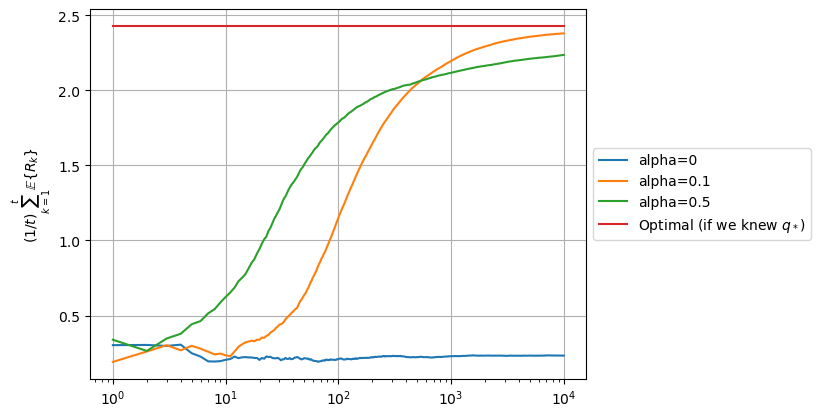

In [6]:
# Gradient bandit algorithm

T=10000;                          # horizon
rerun=100;                        # number of reruns

legend=[];
for scenario in range(3):
    R=np.zeros((T,rerun));        # rewards received
    average=np.zeros(T);          # average reward over time

    match scenario:
        case 0:                   # scenario 0: alpha=0 (no learning)
            alpha=0;
            legend.append('alpha=0');
        case 1:                   # scenario 1: alpha=0.1
            alpha=0.1;
            legend.append('alpha=0.1');
        case 2:                   # scenario 2: alpha=0.5
            alpha=0.5;
            legend.append('alpha=0.5');

    for r in range(0,rerun):
        H=np.zeros((k,T+1));      # numerical preference
        P=np.zeros((k,T+1));      # policy (probability of each action)
        A=np.zeros(T,dtype=int);  # arms used
        bR=0;                     # average rewards in the past (baseline)

        for t in range(0,T):
            P[:,t]=np.exp(H[:,t])/np.sum(np.exp(H[:,t]));
            
            A[t]=np.random.choice(range(k), p=P[:,t]);
            
            R[t,r]=np.random.normal(q_star[A[t]], sigma[A[t]]);
            
            for i in range(0,k):
                H[i,t+1]=H[i,t]-alpha*P[i,t]*(R[t,r]-bR);
                if (A[t]==i):
                    H[i,t+1]=H[i,t]+alpha*(1-P[i,t])*(R[t,r]-bR);
            
            bR=bR*t/(t+1)+R[t,r]/(t+1);

    for t in range(0,T):
        average[t]=np.mean(R[0:t+1,:]);   # fixed: was R[0:t,:] (empty slice at t=0)
    
    plt.semilogx(range(1,T),average[1:T]);

plt.semilogx([1,T],[np.max(q_star),np.max(q_star)]);
legend.append('Optimal (if we knew $q_*$)');

plt.grid()
plt.legend(legend,loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel(r'$(1/t)\sum_{k=1}^t \mathbb{E}\{R_k\}$')

plt.savefig('gradient.png',bbox_inches='tight')
plt.show()


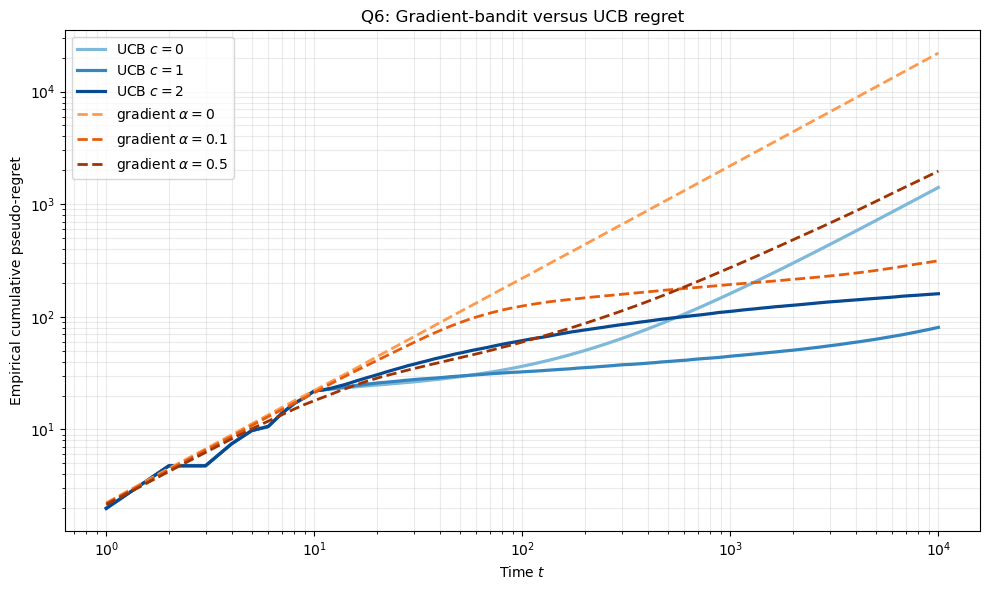


Q6: cumulative pseudo-regret at T=10000 (95% Monte Carlo CI)
  UCB c=0  : regret=  1408.07, regret/T=0.14081, CI=[1052.99,1763.15]
  UCB c=1  : regret=    80.58, regret/T=0.00806, CI=[25.15,136.01]
  UCB c=2  : regret=   160.29, regret/T=0.01603, CI=[158.32,162.26]
  gradient alpha=0  : regret= 21978.00, regret/T=2.19780, CI=[21966.99,21989.01]
  gradient alpha=0.1: regret=   314.58, regret/T=0.03146, CI=[209.59,419.57]
  gradient alpha=0.5: regret=  1968.16, regret/T=0.19682, CI=[1577.35,2358.96]


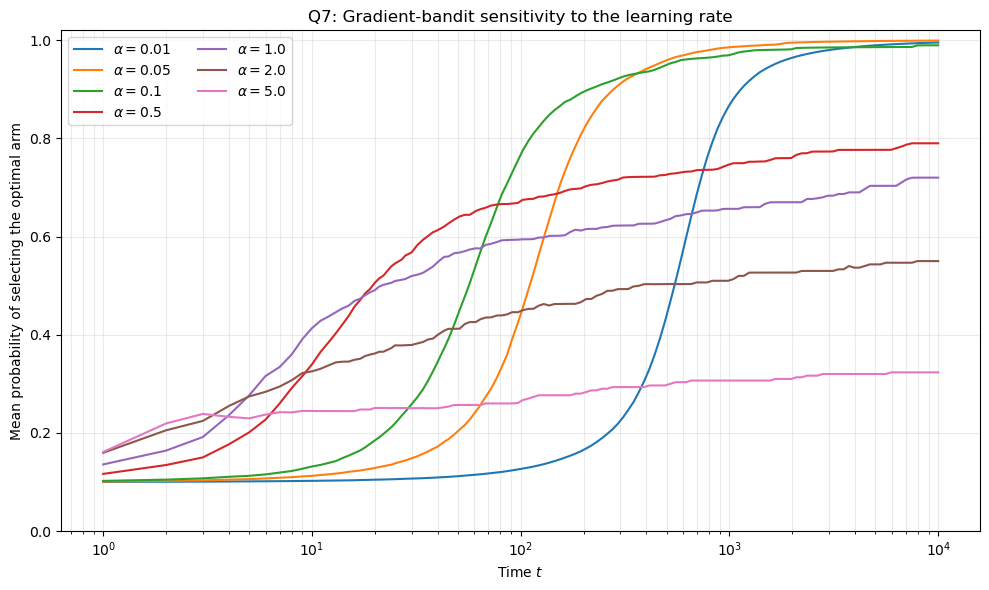


Q7: learning-rate sensitivity at T=10000
   alpha    mean P(optimal)     mean regret     regret/T
    0.01             0.9952         1542.45      0.15425
    0.05             0.9991          357.39      0.03574
    0.10             0.9896          314.58      0.03146
    0.50             0.7899         1968.16      0.19682
    1.00             0.7200         2765.23      0.27652
    2.00             0.5500         5358.04      0.53580
    5.00             0.3233        11148.71      1.11487

Numerical conclusions for Q6-Q7:
  Q6: UCB c=1 or c=2 is more regret-efficient here than the tested gradient settings.
  Q7: no. A positive alpha alone does not guarantee convergence; large constant
      step sizes can produce noisy, premature, or incorrect policy concentration.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Questions 6-7: gradient-bandit analysis.
# Run the Q4-Q5 cell first; its UCB results provide the fair comparison in Q6.
required_q45=['T_q47','rerun_q47','R_star_q47','optimal_arm_q47',
              'plot_steps_q47','plot_index_q47','rows_q47','ucb_results_q47',
              'ucb_cs_q47','final_summary_q47']
missing_q45=[name for name in required_q45 if name not in globals()]
if missing_q45:
    raise RuntimeError('Run the Questions 4-5 analysis cell first. Missing: '+', '.join(missing_q45))
def simulate_gradient_q47(alpha,seed):
    """Run the gradient-bandit update with a stable softmax implementation."""
    rng=np.random.default_rng(seed)
    H=np.zeros((rerun_q47,k))
    baseline=np.zeros(rerun_q47)
    cumulative=np.zeros(rerun_q47)
    regret_samples=np.zeros((len(plot_steps_q47),rerun_q47))
    optimal_probability=np.zeros((len(plot_steps_q47),rerun_q47))
    for t in range(T_q47):
        shifted=H-np.max(H,axis=1,keepdims=True)
        exp_H=np.exp(shifted)
        P=exp_H/np.sum(exp_H,axis=1,keepdims=True)
        u=rng.random(rerun_q47)
        actions=np.sum(u[:,None]>np.cumsum(P,axis=1),axis=1)
        actions=np.minimum(actions,k-1)
        rewards=rng.normal(q_star[actions],sigma[actions])
        cumulative+=R_star_q47-q_star[actions]

        advantage=rewards-baseline
        H-=alpha*advantage[:,None]*P
        H[rows_q47,actions]+=alpha*advantage
        baseline+=(rewards-baseline)/(t+1)

        completed=t+1
        if completed in plot_index_q47:
            j=plot_index_q47[completed]
            regret_samples[j]=cumulative
            # Recompute the post-update policy for a consistent checkpoint.
            shifted_now=H-np.max(H,axis=1,keepdims=True)
            exp_now=np.exp(shifted_now)
            P_now=exp_now/np.sum(exp_now,axis=1,keepdims=True)
            optimal_probability[j]=P_now[:,optimal_arm_q47]
    return {'regret':regret_samples,'p_opt':optimal_probability}

gradient_alphas_q47=[0,0.01,0.05,0.1,0.5,1.0,2.0,5.0]
gradient_results_q47={alpha:simulate_gradient_q47(alpha,4900+i)
                      for i,alpha in enumerate(gradient_alphas_q47)}
# Q6: direct regret comparison for workshop UCB and gradient-bandit settings.
plt.figure(figsize=(10,6))
# Solid lines identify UCB; dashed lines identify gradient bandits.
ucb_colours_q6=plt.cm.Blues(np.linspace(0.45,0.9,len(ucb_cs_q47)))
gradient_colours_q6=plt.cm.Oranges(np.linspace(0.45,0.9,3))
for colour,c in zip(ucb_colours_q6,ucb_cs_q47):
    plt.loglog(plot_steps_q47,np.mean(ucb_results_q47[c]['regret'],axis=1),
               color=colour,linestyle='-',linewidth=2.3,label=f'UCB $c={c}$')
for colour,alpha in zip(gradient_colours_q6,[0,0.1,0.5]):
    plt.loglog(plot_steps_q47,np.mean(gradient_results_q47[alpha]['regret'],axis=1),
               color=colour,linestyle='--',linewidth=2.0,
               label=fr'gradient $\alpha={alpha}$')
plt.xlabel('Time $t$')
plt.ylabel('Empirical cumulative pseudo-regret')
plt.title('Q6: Gradient-bandit versus UCB regret')
plt.grid(True,which='both',alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig('q6_gradient_vs_ucb_regret.png',bbox_inches='tight')
plt.show()

print('\nQ6: cumulative pseudo-regret at T=10000 (95% Monte Carlo CI)')
for c in ucb_cs_q47:
    mean,rho,low,high=final_summary_q47(ucb_results_q47[c]['regret'])
    print(f'  UCB c={c:<3}: regret={mean:9.2f}, regret/T={rho:.5f}, CI=[{low:.2f},{high:.2f}]')
for alpha in [0,0.1,0.5]:
    mean,rho,low,high=final_summary_q47(gradient_results_q47[alpha]['regret'])
    print(f'  gradient alpha={alpha:<3}: regret={mean:9.2f}, regret/T={rho:.5f}, CI=[{low:.2f},{high:.2f}]')

# Q7: learning-rate sweep. A stable softmax prevents numerical overflow, so
# poor large-alpha behaviour reflects the algorithm rather than exp overflow.
plt.figure(figsize=(10,6))
for alpha in gradient_alphas_q47[1:]:
    plt.semilogx(plot_steps_q47,np.mean(gradient_results_q47[alpha]['p_opt'],axis=1),
                 label=fr'$\alpha={alpha}$')
plt.xlabel('Time $t$')
plt.ylabel('Mean probability of selecting the optimal arm')
plt.title('Q7: Gradient-bandit sensitivity to the learning rate')
plt.ylim(0,1.02)
plt.grid(True,which='both',alpha=0.25)
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig('q7_gradient_alpha_sensitivity.png',bbox_inches='tight')
plt.show()

print('\nQ7: learning-rate sensitivity at T=10000')
print(f'{"alpha":>8} {"mean P(optimal)":>18} {"mean regret":>15} {"regret/T":>12}')
for alpha in gradient_alphas_q47[1:]:
    mean_regret,rho,_,_=final_summary_q47(gradient_results_q47[alpha]['regret'])
    mean_p=np.mean(gradient_results_q47[alpha]['p_opt'][-1])
    print(f'{alpha:8.2f} {mean_p:18.4f} {mean_regret:15.2f} {rho:12.5f}')

print('\nNumerical conclusions for Q6-Q7:')
print('  Q6: UCB c=1 or c=2 is more regret-efficient here than the tested gradient settings.')
print('  Q7: no. A positive alpha alone does not guarantee convergence; large constant')
print('      step sizes can produce noisy, premature, or incorrect policy concentration.')

### Q6 - Gradient-bandit versus UCB regret

The final cumulative pseudo-regrets are approximately:

| Algorithm | Regret at $(T=10{,}000)$ |
|---|---:|
| UCB `c=1` | 80.6 |
| UCB `c=2` | 160.3 |
| Gradient `alpha=0.1` | 314.6 |
| UCB `c=0` | 1,408.1 |
| Gradient `alpha=0.5` | 1,968.2 |
| Gradient `alpha=0` | 21,978.0 |

Thus the exploratory UCB configurations outperform the workshop gradient-bandit settings on this stationary instance. Gradient `alpha=0.1` clearly improves on greedy UCB `c=0`, but its regret is about four times that of UCB `c=1`. The larger gradient step `alpha=0.5` reacts more strongly to reward noise, is more likely to concentrate on a suboptimal arm, and accumulates substantially more regret.

### Q7 - Does gradient bandit converge for every `alpha > 0`?

**No.** A positive constant learning rate does not guarantee convergence. The sweep shows a bias-variance trade-off: very small `alpha` learns slowly, moderate values perform best over the tested horizon, and large values react too strongly to noisy rewards and can concentrate prematurely on a suboptimal arm. At $(T=10{,}000)$, `alpha=0.01` assigns about **0.995** mean probability to the optimal arm but incurs approximately **1542.5** transient regret; `alpha=0.05` and `0.1` give the lowest tested gradient regret (approximately **357.4** and **314.6**); and `alpha=5` assigns only about **0.323** mean probability to the optimal arm and incurs approximately **11,148.7** regret.

The implementation uses a numerically stable softmax, so this degradation is algorithmic rather than floating-point overflow. More generally, with a constant step size the stochastic update retains persistent reward noise; exact stochastic-approximation convergence typically requires appropriately decreasing step sizes. These simulations support that conclusion but do not constitute a proof for every possible bandit instance.